### Assignment 3
Python Programming for Business Intelligence
#### Matias Wahlstedt

### AI Statement
- Help to load the emails and news csv file, as it was not normally comma delimited so pd.read_csv did not read it correctly
- overall error troubleshooting and as a last option after googling and using forums like stackoverflow which sometimes did not have the answer to my exact problems
- used a bit more in the later parts of task 3 as these tasks were more demanding, mainly for understanding certain functions and why/how they were to be used. 


### Task 0: Setting up Ollama (1p)
a) Set up Ollama and connect to it using either openAI's API or Ollama's own API.

Downloaded ollama from the web, installed it locally, pulled llama 3.2, gemma3:4b and gemma3:270m. Also did not need to install openai as I had it installed from before. 

In [218]:
from openai import OpenAI

client = OpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama"
)

b) Load the 270m parameter version of the gemma3 model and test it with any prompt.

In [219]:
def ask_270m(prompt):
    """Send a prompt to the local LLM and return the response text."""
    response = client.chat.completions.create(
        model="gemma3:270m",
        messages=[
            {"role": "user", "content": prompt}
        ]
    )
    return response.choices[0].message.content

print(ask_270m("Explain what python pandas are in one sentence."))

Python pandas is a powerful and versatile library for data manipulation and analysis, offering a clean and efficient way to work with sequential data.



c) Load the 4b parameter version of the gemma3 and test it with any prompt. If running the 4b version is too slow, you can use the 1b version instead.

In [220]:
def ask_4b(prompt):
    """Send a prompt to the local LLM and return the response text."""
    response = client.chat.completions.create(
        model="gemma3:4b",
        messages=[
            {"role": "user", "content": prompt}
        ]
    )
    return response.choices[0].message.content
    
print(ask_4b("Explain what python pandas are in one sentence."))

Python Pandas are a powerful library providing data structures – like DataFrames and Series – and data analysis tools designed for working with structured data, making it easier to clean, analyze, and manipulate data in a way similar to spreadsheets.


### Task 1: Text classification with Ollama (2p)

In [221]:
import pandas as pd
# Importing email data
with open("emails.csv", "r", encoding="utf-8") as f:
    lines = f.read().splitlines()

emails = pd.DataFrame(lines[1:], columns=["headline"])
display(emails)

,headline
0,URGENT: Your account will be suspended within 24 hours
1,"Congratulations! You have won a 1000€ gift card, claim now"
2,Hot singles in your area are waiting to meet you tonight
3,Re: Inheritance transfer of 4.5M USD pending your approval
4,Meeting agenda for Thursday's project review
5,"Q3 budget report attached, please review by Friday"
6,Reminder: Annual performance review scheduled for next week
7,"Updated draft of the manuscript, comments welcome"
8,Quick question about last week
9,Following up


a) Make a function for classifying emails (based on the headlines) as spam, work or unknown. The function should return only the classification and nothing else. (0.5p)

In [222]:
def classify_email_270m(headline):
    """Classify an email headline using gemma3:270m."""
    prompt = f"""Classify the following email headline into exactly one of these categories: work, unknown.
Respond with only one word, nothing else.

spam
work
unknown

Rules:
- Return only one word.
- Do not explain.
- Use "spam" for suspicious, promotional, scam-like, or unwanted emails.
- Use "work" for legitimate workplace, business, meeting, or task-related emails.
- Use "unknown" if the headline is too vague to confidently classify.

Headline: {headline}"""
    
    result = ask_270m(prompt)
    return result.strip().lower()

In [223]:
#testing
print(classify_email_270m(emails.loc[7, "headline"]))

work


b) Use the smaller gemma3 (270m) to classify the emails using the function created in part a. (0.5p)

In [224]:
emails_270m = emails.copy()

emails_270m["classification_270m"] = emails_270m["headline"].apply(classify_email_270m)

display(emails_270m)

,headline,classification_270m
0,URGENT: Your account will be suspended within 24 hours,spam
1,"Congratulations! You have won a 1000€ gift card, claim now",spam
2,Hot singles in your area are waiting to meet you tonight,work
3,Re: Inheritance transfer of 4.5M USD pending your approval,unknown
4,Meeting agenda for Thursday's project review,work
5,"Q3 budget report attached, please review by Friday",unknown
6,Reminder: Annual performance review scheduled for next week,unknown
7,"Updated draft of the manuscript, comments welcome",spam
8,Quick question about last week,spam
9,Following up,spam


c) Use larger gemma3 (4b) to classify the emails using the function created in part a). In separate markdown cell, write a brief comment comparing the results of parts b) and c). (0.5p)

In [225]:
# First creating a similar function with the 4b model 
def classify_email_4b(headline):
    """Classify an email headline using gemma3:4b."""
    prompt = f"""Classify the following email headline into exactly one of these categories: work, unknown.
Respond with only one word, nothing else.

spam
work
unknown

Rules:
- Return only one word.
- Do not explain.
- Use "spam" for suspicious, promotional, scam-like, or unwanted emails.
- Use "work" for legitimate workplace, business, meeting, or task-related emails.
- Use "unknown" if the headline is too vague to confidently classify.

Headline: {headline}"""
    
    result = ask_4b(prompt)
    return result.strip().lower()

emails_4b = emails.copy()

emails_4b["classification_4b"] = emails_4b["headline"].apply(classify_email_4b)

pd.set_option('display.max_colwidth', None) # display full line
display(emails_4b)

,headline,classification_4b
0,URGENT: Your account will be suspended within 24 hours,spam
1,"Congratulations! You have won a 1000€ gift card, claim now",spam
2,Hot singles in your area are waiting to meet you tonight,spam
3,Re: Inheritance transfer of 4.5M USD pending your approval,unknown
4,Meeting agenda for Thursday's project review,work
5,"Q3 budget report attached, please review by Friday",work
6,Reminder: Annual performance review scheduled for next week,work
7,"Updated draft of the manuscript, comments welcome",work
8,Quick question about last week,work
9,Following up,work


d) Write a script that repeats b) and c) 3 times, storing the results for both models separately. For both models, put the results as columns into a new DataFrame that also contains the headlines so that it is easy to compare how the output varied across runs for both models. Comment if there were differences and explain why this happened. (0.5p)

In [226]:
repeated_results = emails.copy()

for i in range(1, 4):
    repeated_results[f"270m_run_{i}"] = repeated_results["headline"].apply(classify_email_270m)

for i in range(1, 4):
    repeated_results[f"4b_run_{i}"] = repeated_results["headline"].apply(classify_email_4b)

display(repeated_results)

,headline,270m_run_1,270m_run_2,270m_run_3,4b_run_1,4b_run_2,4b_run_3
0,URGENT: Your account will be suspended within 24 hours,spam,work,unknown,spam,spam,spam
1,"Congratulations! You have won a 1000€ gift card, claim now",spam,work,spam,spam,spam,spam
2,Hot singles in your area are waiting to meet you tonight,work,work,unknown,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending your approval,spam,work,unknown,unknown,unknown,unknown
4,Meeting agenda for Thursday's project review,unknown,meeting,unknown,work,work,work
5,"Q3 budget report attached, please review by Friday",unknown,work,work,work,work,work
6,Reminder: Annual performance review scheduled for next week,work,work,work,work,work,work
7,"Updated draft of the manuscript, comments welcome",work,text,work,work,work,work
8,Quick question about last week,spam,spam,work,work,work,work
9,Following up,spam,work,spam,work,work,work


The larger model 4b seems to be more consistant and in fact returns the same results for all headlines for all three runs. This is not the case with the more limited version 270m, which in almost all headlines switches between the three categories. For headlines 4 and 7 it even prints words that are not one of the three categories defined in the promt, showing the differences in model versions do play a big role, and in this task especially with more vague headlines. This occurs because LLMs are probabilistic, and smaller models like the 270m are more inconsistant. 

### Task 2: Sentiment analysis with Ollama (2p)

In [227]:
# Importing news data
with open("news.csv", "r", encoding="utf-8") as f:
    lines = f.read().splitlines()

news = pd.DataFrame(lines[1:], columns=["headline"])
display(news)

,headline
0,Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%
1,Helvora Pharmaceuticals misses earnings forecast amid weak generics demand
2,"Aurelis Bank reports steady quarterly profit, in line with analyst expectations"
3,Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal
4,Antitrust regulators block proposed merger between Solenta and Marvex Energy
5,Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG
6,New EU AI Act compliance rules expected to raise costs for Lumavex by 12%
7,Finnish FSA grants Norvik Capital expanded licence for cross-border operations
8,"Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs"
9,Rising interest rates weigh on Tessaro Real Estate as financing costs climb


a) Make a function for classifying the texts in the provided dataset based on the topic (earnings, mergers, regulation, macroeconomics) and for determining the sentiment of the news (positive, negative, neutral). The function should return the class and sentiment in JSON format. (1p)

In [228]:
import json

def news_classified(headline):
    """Classify news headline into topic and sentiment, return JSON."""
    
    prompt = f"""Classify the following financial news headline.

Topics: earnings, mergers, regulation, macroeconomics
Sentiment: positive, negative, neutral

Return your answer as a JSON object with two keys:
- "topic": one of the topics above
- "sentiment": one of the sentiments above

Do NOT include any explanation or extra text.
Return ONLY valid JSON.

Headline: "{headline}"
"""
    
    result = ask_4b(prompt)
    
    # Clean possible markdown formatting
    cleaned = result.strip() \
        .removeprefix("```json") \
        .removeprefix("```") \
        .removesuffix("```") \
        .strip()
    
    try:
        return json.loads(cleaned)
    except:
        return {"topic": "", "sentiment": ""}

In [229]:
#testing the function
print(news_classified("Company reports record profits in Q3"))

{'topic': 'earnings', 'sentiment': 'positive'}


b) Use gemma3 (4b) to classify and provide the sentiment for each row of the provided dataset, inserting them into a new DataFrame that contains both the original headlines as well as topic and sentiment. (0.5p)

In [230]:
results = news["headline"].apply(news_classified)

news["topic"] = results.apply(lambda x: x["topic"])
news["sentiment"] = results.apply(lambda x: x["sentiment"])

display(news)

,headline,topic,sentiment
0,Nordion Industries beats Q1 earnings estimates as cloud revenue surges 28%,earnings,positive
1,Helvora Pharmaceuticals misses earnings forecast amid weak generics demand,earnings,negative
2,"Aurelis Bank reports steady quarterly profit, in line with analyst expectations",earnings,positive
3,Veridyne Logistics to acquire rival Trantec in 4.2 billion euro deal,mergers,positive
4,Antitrust regulators block proposed merger between Solenta and Marvex Energy,regulation,negative
5,Kestrel Semiconductor confirms early-stage merger talks with Aldenfeld AG,mergers,neutral
6,New EU AI Act compliance rules expected to raise costs for Lumavex by 12%,regulation,negative
7,Finnish FSA grants Norvik Capital expanded licence for cross-border operations,regulation,positive
8,"Eurozone inflation cools to 2.1%, easing pressure on Drava Holdings borrowing costs",macroeconomics,positive
9,Rising interest rates weigh on Tessaro Real Estate as financing costs climb,macroeconomics,negative


c) Give the same data and prompt to a browser based LLM (e.g. ChatGPT, LeChat, Claude or Gemini) and ask it to provide the topic and sentiment, giving it the same options. Paste the results into a markdown cell. Compare the results of b) and c), which one is more accurate and why? (0.5p)

Output from ChatGPT with the same promt as in b):

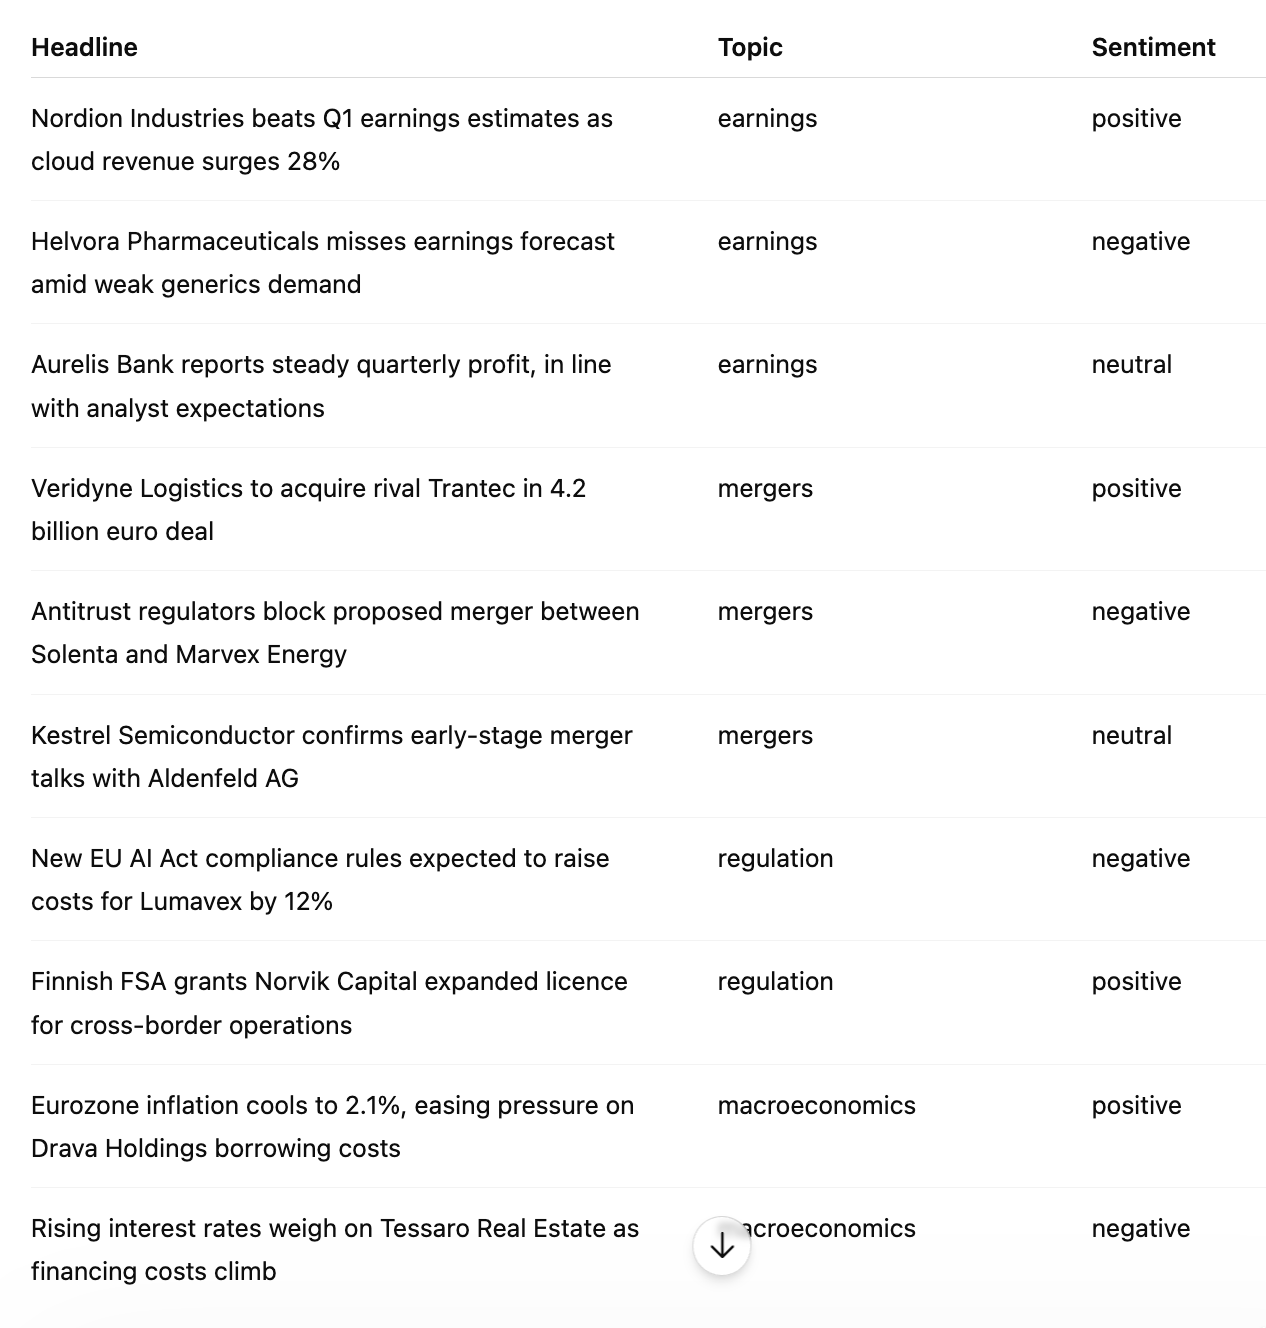

Overall there are not too many differences, and both models did a fairly good job of categorising the news headlines by topic and sentiment. The Aurelis headline is neutral for ChatGPT and positive for gemma3:4b, and I would actually classify this one as positive. For the Antitrust news, 4b gives regulation and ChatGPT mergers, which is here more accurate in my opinion. These are the only ones that differ, however there are a couple ones I would categorise differently. On paper, ChatGPT should be more accurate as it is both larger and browser-based LLM, while 4b is locally stored and much smaller with limited reach. The results depend of course on which model to use, if 270m had been used the results would probably have been more different between the models as it is a much smaller model than 4b. 

### Task 3: Supervised machine learning (5p)

a) Import the dataset and conduct exploratory data analysis on it. (1p)

Dataset downloaded from UCI repository: https://archive.ics.uci.edu/dataset/222/bank+marketing 

In [244]:
# importing the dataset and viewing head
bank = pd.read_csv("bank-additional.csv", sep=";")
bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [245]:
#basic info
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [246]:
# descriptives
bank.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [247]:
# checking the dependent variable
bank["y"].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

In [248]:
#checking missing values
bank.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

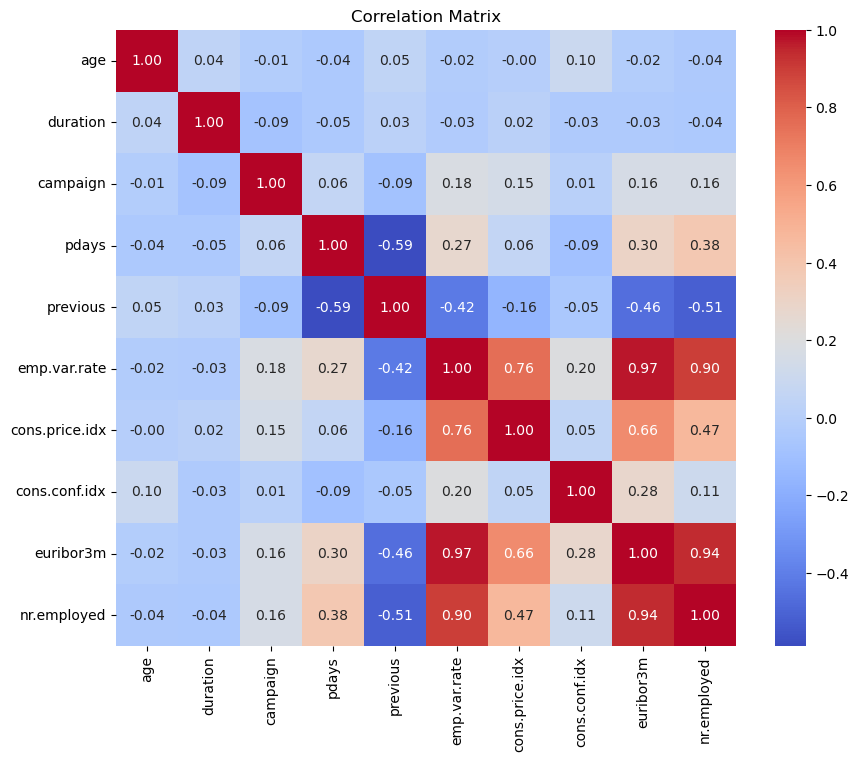

In [249]:
# correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt
numeric_cols = bank.select_dtypes(include=["int64", "float64"])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

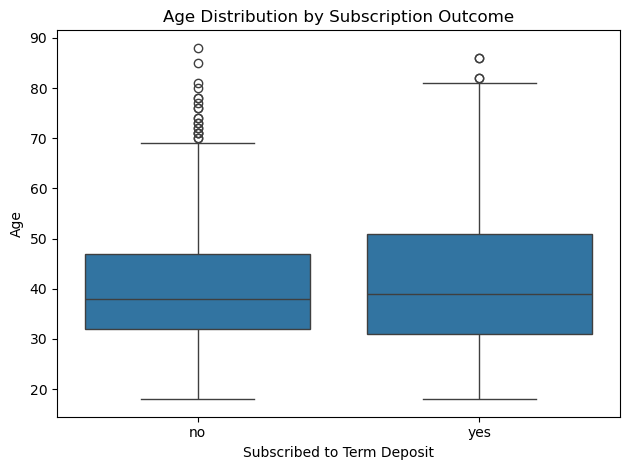

In [250]:
# Box plot of age by subscription outcome
sns.boxplot(x="y", y="age", data=bank)
plt.title("Age Distribution by Subscription Outcome")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

#### EDA Summary
The dataset contains information about bank clients and whether they subscribed to a term deposit (variable y). The target variable is fairly unbalanced, with significantly more "no" than "yes" responses. The dataset includes both numerical and categorical variables such as age, job, marital status, and previous campaign outcomes. Missing values are represented as "unknown" rather than actual null values. The correlation matrix shows strong positive relationships between economic variables such as euribor3m, nr.employed, and emp.var.rate, indicating they move together, while most other variables have weak correlations. 

b) Preprocess the data using the appropriate methods as described in the course materials. (1p)

In [251]:
from sklearn.preprocessing import StandardScaler

bankv2 = bank.copy()

# Encode target variable
bankv2["y"] = bankv2["y"].map({"yes": 1, "no": 0})

# Set target and features
y = bankv2["y"]
X = bankv2.drop(columns=["y"])

# categorical variables to dummies
X = pd.get_dummies(X, drop_first=True, dtype=float)

# Standardize numerical variables
scaler = StandardScaler()

numeric_columns = [
    "age", "duration", "campaign", "pdays", "previous",
    "emp.var.rate", "cons.price.idx", "cons.conf.idx",
    "euribor3m", "nr.employed"
]

X[numeric_columns] = scaler.fit_transform(X[numeric_columns])

display(X.head())
y.value_counts()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,-0.980752,0.903952,-0.209228,0.201031,-0.351356,-1.206054,-1.185448,-1.240939,-1.331707,-0.914779,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,-0.107991,0.350300,0.569634,0.201031,-0.351356,0.649441,0.715193,0.892269,0.711698,0.332862,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,-1.465619,-0.116966,-0.598660,0.201031,-0.351356,0.841389,1.528273,-0.283172,0.773427,0.836535,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,-0.204965,-0.941553,0.180203,0.201031,-0.351356,0.841389,1.528273,-0.283172,0.771697,0.836535,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.667795,-0.780563,-0.598660,0.201031,-0.351356,-0.118350,-0.655478,-0.326707,0.328632,0.398028,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


y
0    3668
1     451
Name: count, dtype: int64

c) Determine whether this is a classification or regression task. Choose three different machine learning algorithms from scikit-learn and explain briefly why you chose them. For each of the selected algorithsm, train and a model and iteratively adjust the hyperparameters until you no longer manage to improve the performance. (1p)

##### This is a classification task because the target variable `y` is categorical. 

- KNN was chosen as a simple instance-based baseline that requires no assumptions about data distribution.
- Random Forest was chosen because it handles class imbalance well with `class_weight="balanced"` and is robust to irrelevant features.
- SVM was chosen because it works well in high-dimensional spaces and can also handle imbalanced classes effectively.

In [252]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train-validation-test split (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print("Train set size:", X_train.shape[0])
print("Validation set size:", X_val.shape[0])
print("Test set size:", X_test.shape[0])

Train set size: 2471
Validation set size: 824
Test set size: 824


In [253]:
# Train initial models on training set and predict on validation set
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_val)

rf_model = RandomForestClassifier(random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)

svm_model = SVC(random_state=42, class_weight="balanced")
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_val)

for name, y_pred in [("KNN", y_pred_knn), ("Random Forest", y_pred_rf), ("SVM", y_pred_svm)]:
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_val, y_pred):.4f}")
    print(f"Precision: {precision_score(y_val, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_val, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_val, y_pred):.4f}")
    print()

--- KNN ---
Accuracy:  0.9053
Precision: 0.6200
Recall:    0.3444
F1-score:  0.4429

--- Random Forest ---
Accuracy:  0.9041
Precision: 0.6410
Recall:    0.2778
F1-score:  0.3876

--- SVM ---
Accuracy:  0.8774
Precision: 0.4663
Recall:    0.8444
F1-score:  0.6008



##### Hyperparameter tuning

In [254]:
# KNN - tune n_neighbors
param_grid_knn = {"n_neighbors": [3, 5, 7, 9, 11, 15, 21]}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring="recall", n_jobs=-1)
grid_knn.fit(X_train, y_train)
print("Best KNN parameters:", grid_knn.best_params_)
print("Best KNN Recall (CV):", f"{grid_knn.best_score_:.4f}")
y_pred_knn_tuned = grid_knn.best_estimator_.predict(X_val)
print("Validation Recall:", f"{recall_score(y_val, y_pred_knn_tuned):.4f}")

Best KNN parameters: {'n_neighbors': 3}
Best KNN Recall (CV): 0.4098
Validation Recall: 0.3000


In [255]:
# Random Forest - tune n_estimators, max_depth, bootstrap
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "bootstrap": [True, False]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, class_weight="balanced"), param_grid_rf, cv=5, scoring="recall", n_jobs=-1)
grid_rf.fit(X_train, y_train)
print("Best RF parameters:", grid_rf.best_params_)
print("Best RF Recall (CV):", f"{grid_rf.best_score_:.4f}")
y_pred_rf_tuned = grid_rf.best_estimator_.predict(X_val)
print("Validation Recall:", f"{recall_score(y_val, y_pred_rf_tuned):.4f}")

Best RF parameters: {'bootstrap': False, 'max_depth': 5, 'n_estimators': 100}
Best RF Recall (CV): 0.7969
Validation Recall: 0.8222


In [256]:
# SVM - tune C and gamma
param_grid_svm = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.1],
    "kernel": ["rbf"]
}
grid_svm = GridSearchCV(SVC(random_state=42, class_weight="balanced"), param_grid_svm, cv=5, scoring="recall", n_jobs=-1)
grid_svm.fit(X_train, y_train)
print("Best SVM parameters:", grid_svm.best_params_)
print("Best SVM Recall (CV):", f"{grid_svm.best_score_:.4f}")
y_pred_svm_tuned = grid_svm.best_estimator_.predict(X_val)
print("Validation Recall:", f"{recall_score(y_val, y_pred_svm_tuned):.4f}")

Best SVM parameters: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
Best SVM Recall (CV): 0.8710
Validation Recall: 0.8889


d) Compare using train, validation and test set split versus using cross-validation. Which one performs better? (1p)

In [257]:
from sklearn.model_selection import cross_val_score

# Validation set recall for each tuned model (already computed above)
print("--- Validation Set Recall ---")
print(f"KNN:           {recall_score(y_val, y_pred_knn_tuned):.4f}")
print(f"Random Forest: {recall_score(y_val, y_pred_rf_tuned):.4f}")
print(f"SVM:           {recall_score(y_val, y_pred_svm_tuned):.4f}")
print()

# Cross-validation recall on the full training data (X_temp = train+val)
print("--- Cross-Validation Recall ---")
for name, estimator in [("KNN", grid_knn.best_estimator_), ("Random Forest", grid_rf.best_estimator_), ("SVM", grid_svm.best_estimator_)]:
    cv_scores = cross_val_score(estimator, X_temp, y_temp, cv=5, scoring="recall")
    print(f"{name}: {cv_scores.mean():.4f}")

--- Validation Set Recall ---
KNN:           0.3000
Random Forest: 0.8222
SVM:           0.8889

--- Cross-Validation Recall ---
KNN: 0.3851
Random Forest: 0.8477
SVM: 0.9032


Cross-validation gives consistently higher recall estimates than the single validation set split for all three models (KNN: 0.39 vs 0.30, RF: 0.85 vs 0.82, SVM: 0.90 vs 0.89). This is expected, since cross-validation averages results over multiple splits of the data rather than relying on just one, making it a more stable and reliable estimate. Both methods agree on the ranking of models where SVM performs best, followed by Random Forest, with KNN clearly the weakest.

e) Report and evaluate the performance of the models using several of the metrics provided in the course, and explain which model is the best for the task and why. (1p)

In [258]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Final evaluation of all three tuned models on the test set
print("--- Final Evaluation on Test Set ---\n")
for name, grid in [("KNN", grid_knn), ("Random Forest", grid_rf), ("SVM", grid_svm)]:
    y_pred = grid.best_estimator_.predict(X_test)
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
    print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")
    print()

--- Final Evaluation on Test Set ---

--- KNN ---
Accuracy:  0.9017
Precision: 0.6000
Recall:    0.3000
F1-score:  0.4000

--- Random Forest ---
Accuracy:  0.8726
Precision: 0.4476
Recall:    0.7111
F1-score:  0.5494

--- SVM ---
Accuracy:  0.8617
Precision: 0.4318
Recall:    0.8444
F1-score:  0.5714



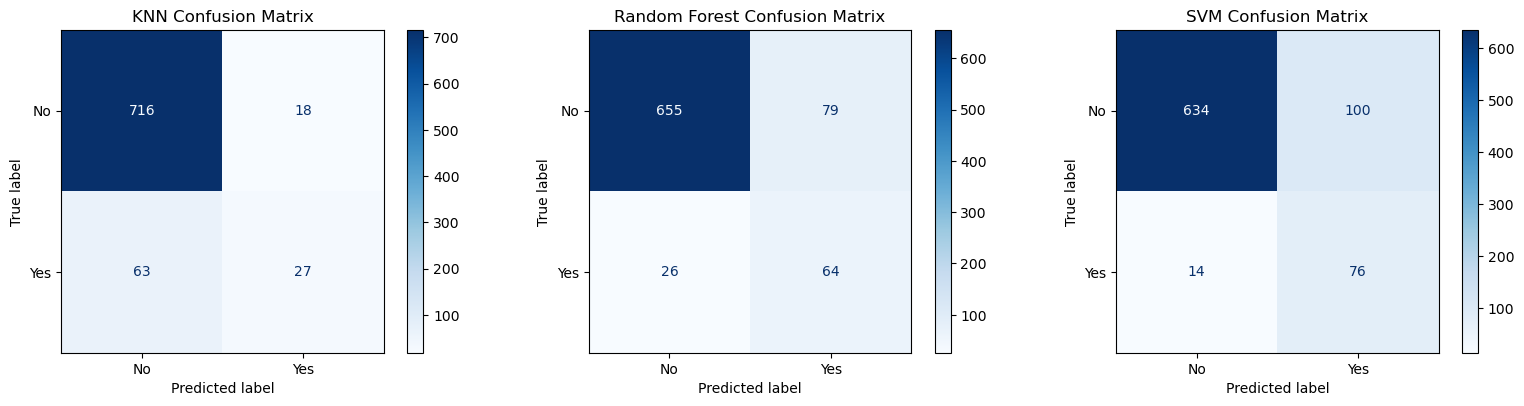

In [259]:
# Confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (name, grid) in zip(axes, [("KNN", grid_knn), ("Random Forest", grid_rf), ("SVM", grid_svm)]):
    y_pred = grid.best_estimator_.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No", "Yes"])
    disp.plot(ax=ax, cmap="Blues")
    ax.set_title(f"{name} Confusion Matrix")

plt.tight_layout()
plt.show()

The dataset is heavily imbalanced, with far more "no" than "yes" responses, which means accuracy alone is not a useful metric. KNN scores 90% accuracy but only correctly identifies 30% of actual subscribers, making it the worst performing model for this task. Since the goal is to find customers likely to subscribe, recall matters most. SVM performs best overall, with the highest recall (0.84) and F1-score (0.57) on the test set. Random Forest comes in second with decent recall (0.71) but misses more subscribers than SVM. KNN is the weakest of the three despite its high accuracy, as it largely fails to detect the minority class.